<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 10px;">
    <h1 style="color:#e2b96f; font-family:'Segoe UI', sans-serif; font-size:2.2em; margin:0 0 8px 0;">
        Chatbots e Introdução ao ML
    </h1>
    <h2 style="color:#a8d8ea; font-family:'Segoe UI', sans-serif; font-size:1.3em; margin:0 0 6px 0; font-weight:400;">
        Aula 01 — Do "Olá Mundo" ao Aprendizado de Máquina
    </h2>
    <h3 style="color:#e2b96f; font-family:'Segoe UI', sans-serif; font-size:1.05em; margin:0 0 12px 0; font-weight:500;">
        Teoria e Prática — Chatbots por Regras, NLU e ML
    </h3>
    <p style="color:#ccc; font-family:'Segoe UI', sans-serif; font-size:0.9em; margin:0;">
        Prof. Felipe Amaral
    </p>
</div>

<div style="display:flex; gap:10px; margin-top:10px; flex-wrap:wrap;">
    <span style="background:#0f3460; color:#a8d8ea; padding:5px 14px; border-radius:20px; font-size:0.85em;">FIAP</span>
    <span style="background:#0f3460; color:#a8d8ea; padding:5px 14px; border-radius:20px; font-size:0.85em;">Python 3</span>
    <span style="background:#0f3460; color:#a8d8ea; padding:5px 14px; border-radius:20px; font-size:0.85em;">NLP & Machine Learning</span>
</div>

## Mapa da Aula

> **Como usar este notebook:** execute cada célula com **Shift+Enter**, leia os textos antes do código e acompanhe a explicação. Não pule células!

---

> **Sem pânico!** Você não precisa saber nada sobre Machine Learning para começar. Vamos construir o conhecimento do zero, passo a passo.

| # | Tópico | O que você vai conseguir fazer |
|---|--------|---------------------------------|
| **1** | **O que é um Chatbot?** | Explicar os 3 tipos com exemplos do dia a dia |
| **2** | **Chatbot por Regras** | Entender por que o método mais simples tem um limite |
| **3** | **Arquitetura NLU** | Descrever o caminho de uma mensagem até a resposta |
| **4** | **Seu primeiro modelo de ML** | Treinar um classificador real com scikit-learn |
| **5** | **Chatbot Completo** | Ver como tudo se conecta em um produto profissional |

> **Tempo estimado: 30 minutos**


In [1]:
import re
import random
import json
from collections import defaultdict

# Visualização
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# NLP e Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix

# Configurações de visualização
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid", palette="muted")

print("Bibliotecas carregadas!")
import sklearn; print(f"  scikit-learn {sklearn.__version__} | numpy {np.__version__}")


Bibliotecas carregadas!
  scikit-learn 1.6.1 | numpy 2.0.2


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div>
        <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 1</span>
        <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">O que é um Chatbot?</h2>
        <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Antes de construir, precisamos entender o que estamos construindo."</p>
    </div>
</div>

### Definição simples

> Um **chatbot** é um programa de computador que conversa com pessoas usando linguagem natural — texto ou voz.

Você já interagiu com um hoje. Quando você manda mensagem para o atendimento do banco pelo app e recebe respostas automáticas, quem está respondendo é um chatbot. O assistente virtual da operadora de celular também. E o ChatGPT? Chatbot de última geração.

---

### Como chegamos até aqui? — Linha do Tempo

```
1950          1966          1995          2011          2016          2022
  │             │             │             │             │             │
  ▼             ▼             ▼             ▼             ▼             ▼
[Turing]    [ELIZA]       [ALICE]       [Siri]      [Telegram    [ChatGPT]
 Propõe o   Primeiro      Padrões       Apple        Bots]        LLMs mudam
 Teste de   chatbot       AIML          lança        APIs          tudo
 Turing     (regras)      XML           assistente   abertas
```

| Era | Tecnologia | Exemplo | Limitação |
|-----|-----------|---------|-----------|
| **Regras (1960–2000)** | `if/else`, regex | ELIZA | Frágil fora do script |
| **ML Supervisionado (2000–2020)** | Classificadores, NLU | Watson, Dialogflow | Precisa de dados rotulados |
| **LLMs (2022+)** | Transformers bilionários | ChatGPT, Claude | Custo, alucinações |

---

### Os 3 tipos de chatbot que você precisa conhecer

<div style="display:flex; gap:20px; flex-wrap:wrap; margin:16px 0;">
<div style="flex:1; min-width:200px; background:#e3f2fd; border-radius:10px; padding:16px; border-top:4px solid #1565c0;">
<strong>Baseado em Regras</strong><br><br>
Funciona como um <em>fluxograma</em>:<br>
SE usuário diz X → responde Y<br><br>
Simples e previsível.<br>
Quebra com qualquer variação de linguagem.
</div>
<div style="flex:1; min-width:200px; background:#f3e5f5; border-radius:10px; padding:16px; border-top:4px solid #6a1b9a;">
<strong>Baseado em ML</strong><br><br>
<em>Aprende com exemplos</em> — você mostra centenas de frases rotuladas e o algoritmo aprende o padrão sozinho.<br><br>
Entende variações. Precisa de dados para treinar.
</div>
<div style="flex:1; min-width:200px; background:#fff3e0; border-radius:10px; padding:16px; border-top:4px solid #e65100;">
<strong>LLMs (IA Generativa)</strong><br><br>
Modelo treinado em <em>bilhões de textos</em>, gera respostas livres.<br><br>
Fluência impressionante. Custo alto, pode inventar respostas ("alucinar").
</div>
</div>

<div style="background:#e3f2fd; border-left:5px solid #1565c0; padding:12px 18px; border-radius:6px; margin:12px 0;">
<strong style="color:#1565c0;">Onde entra o Machine Learning nisso?</strong><br>
<span style="color:#1565c0;">O tipo 2 — Baseado em ML — é o foco desta aula. Vamos entender <em>por que</em> as regras manuais têm um limite e <em>como</em> o ML resolve esse problema. O tipo 3 (ChatGPT) usa ML levado ao extremo — os fundamentos que você aprende hoje são a base para entender ele também.</span>
</div>


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div>
        <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 2</span>
        <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Chatbot Baseado em Regras</h2>
        <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"O ELIZA — o avô de todos os chatbots."</p>
    </div>
</div>

### O ELIZA — o avô de todos os chatbots

Em 1966, Joseph Weizenbaum criou o **ELIZA** no MIT. Era um programa simples que usava **substituição de padrões** para simular um psicoterapeuta. As pessoas ficavam tão impressionadas que acreditavam estar falando com um humano!

**Como funciona?** É mais simples do que parece:

```
Usuário: "Eu me sinto triste"
          ↓
    ELIZA procura padrão: "eu me sinto ___"
          ↓
    Substitui: "Por que você se sente triste?"
```

É basicamente **localizar e substituir** — sem nenhuma inteligência real. Nenhum "aprendizado" acontece. O programador escreve cada regra na mão.

### Vamos implementar nosso próprio ELIZA!

O código usa **expressões regulares (regex)** — uma forma de descrever padrões em texto. Não se preocupe com a sintaxe agora, os comentários explicam cada passo.


In [2]:
# ELIZA: Chatbot Baseado em Regras
#
# Conceito: usamos EXPRESSÕES REGULARES (regex) para detectar
# padrões na frase do usuário e gerar uma resposta a partir deles.
#
# Uma regex é uma "receita" para encontrar padrões em texto:
#   r"eu me sinto (.+)"  →  encontra "eu me sinto" + qualquer coisa
#   (.+) é um GRUPO DE CAPTURA — guarda o que veio depois
# ============================================================

import re
import random

# PASSO 1: Definir as regras
# Cada regra é uma tupla: (PADRÃO, RESPOSTA)
# Quando o padrão casa com a frase do usuário, a resposta é usada.
# A resposta pode ser uma string fixa ou uma FUNÇÃO (lambda)
# que usa o texto capturado pelo grupo (.+)

REGRAS_ELIZA = [
    # Saudações
    (r"\b(oi|olá|ola|hey|bom dia|boa tarde|boa noite)\b",
     "Olá! Fico feliz em conversar. Como você está se sentindo hoje?"),

    # "Eu me sinto X" → pergunta por que
    (r"eu me sinto (.+)",
     lambda m: f"Por que você se sente **{m.group(1)}**?"),

    # "Eu (quero/preciso/gostaria) X"
    (r"eu (quero|preciso|gostaria de) (.+)",
     lambda m: f"Por que você {m.group(1)} {m.group(2)}? Isso é importante para você?"),

    # "Eu estou X"
    (r"eu (estou|tô|to) (.+)",
     lambda m: f"Há quanto tempo você está {m.group(2)}?"),

    # "Meu X é/está Y"
    (r"meu (.+?) (é|está|foi|era) (.+)",
     lambda m: f"Interessante. Conte-me mais sobre seu {m.group(1)}."),

    # "Não consigo X"
    (r"não consigo (.+)",
     lambda m: f"O que especificamente te impede de {m.group(1)}?"),

    # Despedida
    (r"\b(tchau|até logo|adeus|até mais|xau)\b",
     "Foi ótimo conversar! Até a próxima. 👋"),
]

# Respostas genéricas, usadas quando nenhuma regra casa
FALLBACKS = [
    "Isso é muito interessante. Pode me contar mais?",
    "E como isso te faz sentir?",
    "Por que você me conta isso?",
    "Vamos explorar esse pensamento com mais profundidade.",
    "Hmm... Continue.",
]

#  PASSO 2: A função principal do chatbot
def eliza_responder(frase_usuario: str) -> str:
    """
    Recebe a frase do usuário, testa cada regra em ordem,
    e retorna a primeira resposta que casar.
    Se nenhuma casar, retorna um fallback aleatório.
    """
    texto = frase_usuario.lower().strip()

    for padrao, resposta in REGRAS_ELIZA:
        match = re.search(padrao, texto)
        if match:
            # Se a resposta é uma função, chama ela passando o match
            if callable(resposta):
                return resposta(match)
            else:
                return resposta

    # Nenhuma regra casou → fallback genérico
    return random.choice(FALLBACKS)


#  PASSO 3: Simulando uma conversa ─
dialogo_teste = [
    "Oi, tudo bem?",
    "Eu me sinto muito ansioso com a faculdade",
    "Eu preciso de mais tempo para estudar",
    "Não consigo focar quando tenho muitas matérias",
    "Meu professor foi muito exigente ontem",
    "Tchau!",
]

print("=" * 60)
print("  SIMULAÇÃO DE CONVERSA — ELIZA (estilo 1966)")
print("=" * 60)

for fala in dialogo_teste:
    resposta = eliza_responder(fala)
    print(f"\n  👤 Você:  {fala}")
    print(f"  🤖 ELIZA: {resposta}")

  SIMULAÇÃO DE CONVERSA — ELIZA (estilo 1966)

  👤 Você:  Oi, tudo bem?
  🤖 ELIZA: Olá! Fico feliz em conversar. Como você está se sentindo hoje?

  👤 Você:  Eu me sinto muito ansioso com a faculdade
  🤖 ELIZA: Por que você se sente **muito ansioso com a faculdade**?

  👤 Você:  Eu preciso de mais tempo para estudar
  🤖 ELIZA: Por que você preciso de mais tempo para estudar? Isso é importante para você?

  👤 Você:  Não consigo focar quando tenho muitas matérias
  🤖 ELIZA: O que especificamente te impede de focar quando tenho muitas matérias?

  👤 Você:  Meu professor foi muito exigente ontem
  🤖 ELIZA: Interessante. Conte-me mais sobre seu professor.

  👤 Você:  Tchau!
  🤖 ELIZA: Foi ótimo conversar! Até a próxima. 👋


  A CONVERSA REAL: pergunta -> resposta do ELIZA

Dentro do script
----------------
  [OK      ] "Eu me sinto cansado"
             -> Por que você se sente **cansado**?
  [OK      ] "Não consigo dormir direito"
             -> O que especificamente te impede de dormir direito?
  [OK      ] "Eu preciso de ajuda"
             -> Por que você preciso de ajuda? Isso é importante para você?
  [OK      ] "Meu chefe é difícil"
             -> Interessante. Conte-me mais sobre seu chefe.
  [OK      ] "Olá!"
             -> Olá! Fico feliz em conversar. Como você está se sentindo hoje?

Fora do script
--------------
  [FALLBACK] "Qual é a capital do Brasil?"
             -> Hmm... Continue.
  [FALLBACK] "Quanto custa o produto X?"
             -> Vamos explorar esse pensamento com mais profundidade.
  [FALLBACK] "Agende uma reunião amanhã"
             -> Por que você me conta isso?
  [FALLBACK] "Me manda o boleto"
             -> E como isso te faz sentir?
  [FALLBACK] "Quero cancelar meu ped

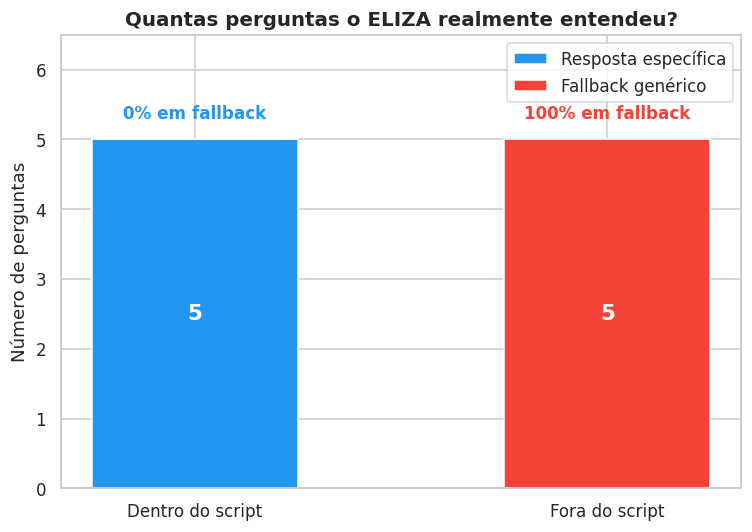


CONCLUSÃO
----------------------------------------
- Chatbots por regras funcionam bem para domínios MUITO limitados.
- Qualquer variação de linguagem 'quebra' o chatbot (cai no fallback).
- Mesmo quando uma regra casa, a resposta pode sair sem sentido
  gramatical -- não há entendimento real, só substituição de texto.

Por que regras manuais não escalam?
  5 intenções      -> ~30 regras escritas à mão
  50 intenções     -> ~300+ regras
  500 intenções    -> praticamente impossível de manter

É por isso que precisamos de Machine Learning: em vez de escrever
regra por regra, mostramos exemplos e deixamos o modelo generalizar.


In [10]:
#  Visualizando as Limitações do Chatbot por Regras
# Em vez de só contar quantas respostas foram "fallback", vamos MOSTRAR
# a conversa real, pergunta a pergunta — é lendo o diálogo que a
# limitação do ELIZA fica óbvia, sem precisar de estatística nenhuma.

# Perguntas variadas — algumas dentro do script, outras fora
perguntas_variadas = {
    "Dentro do script": [
        "Eu me sinto cansado",
        "Não consigo dormir direito",
        "Eu preciso de ajuda",
        "Meu chefe é difícil",
        "Olá!",
    ],
    "Fora do script": [
        "Qual é a capital do Brasil?",
        "Quanto custa o produto X?",
        "Agende uma reunião amanhã",
        "Me manda o boleto",
        "Quero cancelar meu pedido",
    ],
}

# Cores ANSI só para destacar fallback (vermelho) x resposta específica (verde)
VERDE, VERMELHO, RESET = "\033[92m", "\033[91m", "\033[0m"

print("=" * 78)
print("  A CONVERSA REAL: pergunta -> resposta do ELIZA")
print("=" * 78)

resultados = {}
for categoria, perguntas in perguntas_variadas.items():
    print(f"\n{categoria}")
    print("-" * len(categoria))
    fallbacks = 0
    for p in perguntas:
        resposta = eliza_responder(p)
        eh_fallback = resposta in FALLBACKS
        fallbacks += eh_fallback
        cor = VERMELHO if eh_fallback else VERDE
        rotulo = "FALLBACK" if eh_fallback else "OK"
        print(f'  {cor}[{rotulo:8s}]{RESET} "{p}"')
        print(f"             -> {resposta}")
    resultados[categoria] = {
        "Resposta Específica": len(perguntas) - fallbacks,
        "Fallback Genérico": fallbacks,
    }

print("\n" + "=" * 78)
print("Repare: em 'Fora do script', o ELIZA deu respostas genéricas para")
print("perguntas completamente diferentes entre si — capital do Brasil,")
print("preço, agenda, boleto, cancelamento. Ele não entendeu nada disso;")
print("apenas não encontrou nenhum padrão e caiu no fallback.")

exemplo_gramatical = eliza_responder("Eu preciso de ajuda")
print("\nRepare também dentro do script, em 'Eu preciso de ajuda':")
print(f'  -> "{exemplo_gramatical}"')
print("O ELIZA não conjuga verbos, apenas GRUDA o texto capturado no padrão.")
print("Por isso a frase soa estranha: não há entendimento de gramática,")
print("só substituição mecânica de texto.")

#  Gráfico: quantas perguntas o ELIZA realmente entendeu, por categoria
categorias = list(resultados.keys())
especificas = [resultados[c]["Resposta Específica"] for c in categorias]
fallback_count = [resultados[c]["Fallback Genérico"] for c in categorias]
totais = [e + f for e, f in zip(especificas, fallback_count)]

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(categorias, especificas, color="#2196F3", label="Resposta específica", width=0.5)
bars2 = ax.bar(categorias, fallback_count, bottom=especificas,
               color="#F44336", label="Fallback genérico", width=0.5)

ax.set_title("Quantas perguntas o ELIZA realmente entendeu?", fontsize=13, fontweight="bold")
ax.set_ylabel("Número de perguntas")
ax.set_ylim(0, 6.5)
ax.legend()

for bar, val in zip(bars1, especificas):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, str(val),
                ha='center', va='center', color='white', fontweight='bold', fontsize=14)
for bar, val, base in zip(bars2, fallback_count, especificas):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, base + val/2, str(val),
                ha='center', va='center', color='white', fontweight='bold', fontsize=14)

for i, (total, fb) in enumerate(zip(totais, fallback_count)):
    pct = 100 * fb / total
    cor_pct = "#F44336" if pct > 0 else "#2196F3"
    ax.text(i, total + 0.3, f"{pct:.0f}% em fallback", ha='center',
            fontsize=11, fontweight='bold', color=cor_pct)

plt.tight_layout()
plt.savefig("aula01_limitacoes_regras.png", dpi=110, bbox_inches="tight")
plt.show()

print("\nCONCLUSÃO")
print("-" * 40)
print("- Chatbots por regras funcionam bem para domínios MUITO limitados.")
print("- Qualquer variação de linguagem 'quebra' o chatbot (cai no fallback).")
print("- Mesmo quando uma regra casa, a resposta pode sair sem sentido")
print("  gramatical -- não há entendimento real, só substituição de texto.")
print()
print("Por que regras manuais não escalam?")
print(f"  {'5 intenções':<16s} -> ~30 regras escritas à mão")
print(f"  {'50 intenções':<16s} -> ~300+ regras")
print(f"  {'500 intenções':<16s} -> praticamente impossível de manter")
print()
print("É por isso que precisamos de Machine Learning: em vez de escrever")
print("regra por regra, mostramos exemplos e deixamos o modelo generalizar.")


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div>
        <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 3</span>
        <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Arquitetura de um Chatbot Moderno</h2>
        <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"O caminho da mensagem até a resposta."</p>
    </div>
</div>

### O gráfico acima mostrou o problema. E a solução?

Chatbots profissionais não usam regras manuais. Eles usam um **pipeline** — uma sequência de etapas onde cada uma transforma a entrada e passa o resultado para a próxima.

```
┌──────────────────────────────────────────────────────────────┐
│                                                              │
│  👤 "Quero cancelar meu pedido 12345"                        │
│                     │                                        │
│                     ▼                                        │
│         ┌───────────────────────┐                            │
│         │  PRÉ-PROCESSAMENTO    │  → limpar, tokenizar       │
│         └──────────┬────────────┘                            │
│                    ▼                                         │
│         ┌───────────────────────┐                            │
│         │  NLU — ENTENDIMENTO   │  → Intenção: #cancelar     │
│         │  Natural Language     │     Entidade: @pedido=12345│
│         │  Understanding        │                            │
│         └──────────┬────────────┘                            │
│                    ▼                                         │
│         ┌───────────────────────┐                            │
│         │  GERENCIADOR DE       │  → Verifica contexto       │
│         │  DIÁLOGO              │     Decide próximo passo   │
│         └──────────┬────────────┘                            │
│                    ▼                                         │
│         ┌───────────────────────┐                            │
│         │  NLG — GERAÇÃO        │  → Monta a resposta        │
│         └──────────┬────────────┘                            │
│                    ▼                                         │
│  🤖 "Seu pedido 12345 foi cancelado. Reembolso em 5 dias."   │
│                                                              │
└──────────────────────────────────────────────────────────────┘
```

### 3 conceitos que aparecem em todo chatbot profissional

| Conceito | O que é | Exemplo |
|----------|---------|---------|
| **Intenção (Intent)** | O **objetivo** do usuário — o que ele quer fazer | `"quero cancelar"` → `#cancelar_pedido` |
| **Entidade (Entity)** | Os **dados** mencionados na frase | `"pedido 12345"` → `@numero = 12345` |
| **Contexto** | A **memória** da conversa — o que já foi dito | `{"usuario": "Ana", "pedido": "12345"}` |

<div style="background:#e8d5f5; border-left:5px solid #5b2c8d; padding:14px 20px; border-radius:6px; margin:12px 0;">
<strong style="color:#5b2c8d;">Analogia do dia a dia:</strong> <span style="color:#5b2c8d;">Imagine que você liga para uma empresa e fala: <em>"Quero cancelar o pedido que fiz ontem"</em>. O atendente identifica a <strong>intenção</strong> (cancelar pedido), a <strong>entidade</strong> ("ontem" — dado temporal) e consulta o <strong>contexto</strong> (seu histórico de compras). O NLU faz exatamente isso, automaticamente — e é aqui que entra o Machine Learning.</span>
</div>


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div>
        <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 4</span>
        <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Seu Primeiro Modelo de Machine Learning</h2>
        <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Como o computador aprende a classificar intenções?"</p>
    </div>
</div>

### O que é Machine Learning, afinal?

A ideia central é simples: **em vez de programar regras, você mostra exemplos**.

| Abordagem | Como funciona | Analogia |
|-----------|--------------|----------|
| **Programação tradicional** | Você escreve todas as regras | Receita de bolo com cada passo explícito |
| **Machine Learning** | Você mostra exemplos, o algoritmo descobre as regras | Criança que aprende a falar ouvindo adultos |

Para classificar intenções de chatbot, o processo é:

```
TREINO (acontece uma vez):
  Exemplos rotulados → Algoritmo → Modelo (padrões aprendidos)

  "quero cancelar"      → cancelar_pedido  ┐
  "cancela o pedido"    → cancelar_pedido  ├── Algoritmo aprende
  "onde está meu pedido" → rastrear_pedido ┘   o que distingue cada classe

PREDIÇÃO (acontece toda vez que o usuário escreve):
  Nova frase → Modelo → Intenção prevista
  "quero desistir" → ? → cancelar_pedido  ✓ (nunca viu essa frase, mas generalizou!)
```

### Mas o algoritmo não entende texto — e agora?

Algoritmos de ML trabalham com **números**, não palavras. Precisamos transformar texto em vetores numéricos. Para isso usamos o **TF-IDF**:

**TF-IDF** (Term Frequency — Inverse Document Frequency) dá um **peso** para cada palavra, baseado em quão importante ela é para distinguir um tipo de frase dos outros. Palavras que aparecem muito em uma intenção e pouco nas outras recebem peso alto.

```
"quero cancelar meu pedido"
         ↓  TF-IDF
[0.0, 0.8, 0.0, 0.6, 0.0, 0.4, 0.0, ...]
  ↑             ↑             ↑
"cancelar"   "pedido"      "quero"
(peso alto)  (peso alto)  (peso baixo — aparece em todas as intenções)
```

Depois da vetorização, o **classificador** (usaremos Regressão Logística) aprende quais combinações de pesos correspondem a cada intenção.

<div style="background:#e8f5e9; border-left:5px solid #2e7d32; padding:12px 18px; border-radius:6px; margin:12px 0;">
<strong style="color:#2e7d32;">Nas células a seguir você vai:</strong><br>
<span style="color:#2e7d32;">1. Criar um dataset com exemplos rotulados<br>
2. Treinar o modelo com uma única linha de código (<code>.fit()</code>)<br>
3. Testar com frases que o modelo nunca viu<br>
4. Visualizar onde ele acerta e onde erra</span>
</div>


In [4]:
# PASSO 1 — Criar o Dataset de Treinamento
#
# Em ML supervisionado, você precisa de DADOS ROTULADOS:
# cada exemplo tem uma entrada (frase) e uma saída esperada (intenção).
#
# Aqui montamos isso manualmente. Em produção, esses dados vêm
# de conversas reais com usuários, anotadas por uma equipe.
#
# Regra de ouro: quanto mais VARIADOS os exemplos, mais robusto o modelo.
# O modelo aprende a generalizar — não a decorar frases exatas.

DATASET_INTENCOES = {
    "rastrear_pedido": [
        "onde está meu pedido",
        "quero rastrear minha encomenda",
        "qual o status do meu pedido",
        "meu pedido chegou",
        "quando chega minha compra",
        "cadê meu produto",
        "me diz onde tá meu pedido",
        "quero saber onde está minha compra",
        "status da entrega",
        "meu pedido foi enviado",
    ],
    "cancelar_pedido": [
        "quero cancelar",
        "pode cancelar meu pedido",
        "desistir da compra",
        "cancelar minha compra",
        "não quero mais o produto",
        "cancela o pedido",
        "quero desistir da compra",
        "cancela tudo",
        "como faço para cancelar",
        "quero devolver e cancelar",
    ],
    "segunda_via_boleto": [
        "preciso do boleto",
        "segunda via do boleto",
        "reemitir boleto",
        "perdi o boleto",
        "não recebi o boleto",
        "gerar novo boleto",
        "me manda o boleto",
        "quero pagar mas perdi o boleto",
        "boleto vencido",
        "como pago o boleto",
    ],
    "falar_com_humano": [
        "falar com atendente",
        "quero um humano",
        "transferir para atendente",
        "atendimento humano",
        "preciso de um operador",
        "sair do bot",
        "não quero falar com robô",
        "coloca um humano aqui",
        "quero falar com uma pessoa",
        "atendente por favor",
    ],
    "saudacao": [
        "oi",
        "olá",
        "bom dia",
        "boa tarde",
        "boa noite",
        "oi tudo bem",
        "hey",
        "oi como vai",
        "bom dia, tudo bem",
        "olá pode me ajudar",
    ],
}

# Transformar o dicionário em duas listas paralelas:
#   X_treino = lista de frases (entradas)
#   y_treino = lista de intenções correspondentes (saídas esperadas)
# Isso é o formato que o scikit-learn espera.
X_treino = []
y_treino = []
for intencao, exemplos in DATASET_INTENCOES.items():
    for exemplo in exemplos:
        X_treino.append(exemplo)
        y_treino.append(intencao)

print(f"Dataset criado!")
print(f"  Total de exemplos: {len(X_treino)} frases")
print(f"  Número de intenções (classes): {len(DATASET_INTENCOES)}")
print(f"\n  Distribuição por intenção:")
from collections import Counter
for intencao, qtd in Counter(y_treino).items():
    barra = "█" * qtd
    print(f"    {intencao:25s}: {barra} ({qtd})")


Dataset criado!
  Total de exemplos: 50 frases
  Número de intenções (classes): 5

  Distribuição por intenção:
    rastrear_pedido          : ██████████ (10)
    cancelar_pedido          : ██████████ (10)
    segunda_via_boleto       : ██████████ (10)
    falar_com_humano         : ██████████ (10)
    saudacao                 : ██████████ (10)


In [5]:
# PASSO 2 — Treinar o Modelo
#
# Usamos um PIPELINE do scikit-learn — pense como uma linha de montagem:
#
#   Texto bruto
#       ↓
#   TfidfVectorizer  →  transforma cada frase em um vetor de números
#       ↓
#   LogisticRegression  →  aprende quais vetores correspondem a qual intenção
#       ↓
#   Intenção prevista
#
# O Pipeline encadeia os dois passos automaticamente.
# Na hora de treinar, você chama .fit() uma única vez.
# Na hora de prever, você chama .predict() — ele cuida de tudo.

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

classificador_nlu = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",          # analisa por palavras
        ngram_range=(1, 2),       # considera palavras isoladas E pares de palavras
        strip_accents="unicode",  # normaliza acentos
        lowercase=True,           # tudo em minúsculo
    )),
    ("clf", LogisticRegression(
        max_iter=1000,            # tentativas máximas para convergir
        C=5.0,                    # controla a "confiança" do modelo
        random_state=42,          # garante resultados reproduzíveis
    )),
])

# .fit() é onde o aprendizado acontece.
# Internamente: TF-IDF constrói o vocabulário e calcula os pesos,
# depois a Regressão Logística ajusta os coeficientes para minimizar erros.
# Tudo isso em milissegundos com 50 exemplos.
classificador_nlu.fit(X_treino, y_treino)
print("Modelo treinado!")
print()

# PASSO 3 — Testar com frases NOVAS (que o modelo nunca viu)
# Isso simula o que acontece em produção: o usuário digita algo,
# o modelo precisa classificar sem ter visto aquela frase exata antes.
frases_teste = [
    "cadê minha encomenda?",           # nunca apareceu no treino
    "quero desistir",                  # variação de cancelar
    "me manda o boleto de novo",       # variação de boleto
    "preciso falar com alguém",        # variação de humano
    "boa tarde",                       # saudação simples
    "quando meu produto vai chegar?",  # rastrear com palavras diferentes
]

print(f"{'Frase':<45} {'Intenção Prevista':<25} {'Confiança':>10}")
print("-" * 82)

probabilidades = classificador_nlu.predict_proba(frases_teste)
predicoes = classificador_nlu.predict(frases_teste)

for frase, pred, probs in zip(frases_teste, predicoes, probabilidades):
    confianca = probs.max()
    status = "OK " if confianca > 0.7 else "?? "
    print(f"  {status} {frase:<43} {pred:<25} {confianca:>9.1%}")

print()
print("Confiança = certeza do modelo (0% a 100%).")
print("Acima de 70%: o modelo está seguro da classificação.")


Modelo treinado!

Frase                                         Intenção Prevista          Confiança
----------------------------------------------------------------------------------
  ??  cadê minha encomenda?                       rastrear_pedido               62.2%
  ??  quero desistir                              cancelar_pedido               53.6%
  ??  me manda o boleto de novo                   segunda_via_boleto            69.5%
  OK  preciso falar com alguém                    falar_com_humano              73.5%
  OK  boa tarde                                   saudacao                      72.8%
  ??  quando meu produto vai chegar?              rastrear_pedido               56.8%

Confiança = certeza do modelo (0% a 100%).
Acima de 70%: o modelo está seguro da classificação.


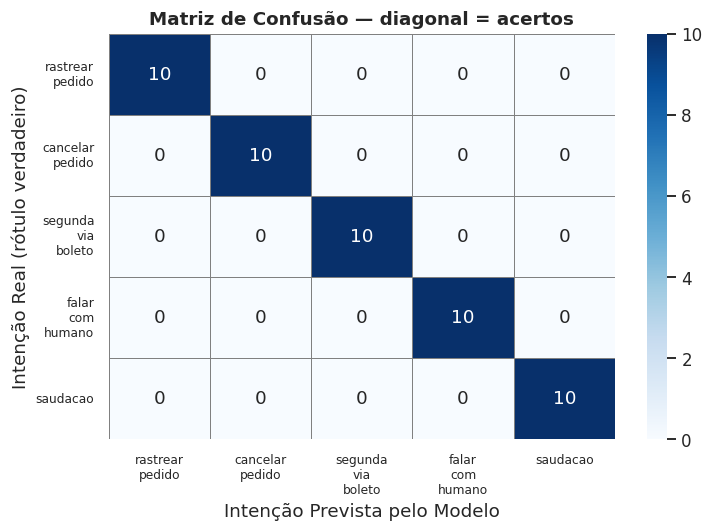

Leia assim:
  Cada LINHA = intenção real | Cada COLUNA = o que o modelo previu
  Diagonal azul escuro = acertos | Qualquer número fora = confusão

Observação: treinamos e testamos nos mesmos dados (para fins didáticos).
Em produção, você separaria parte dos dados só para teste — nunca vistos no treino.


In [6]:
# PASSO 4 — Avaliar o Modelo: Matriz de Confusão
#
# Como saber se o modelo está bom?
# A MATRIZ DE CONFUSÃO mostra, para cada intenção real (linha),
# o que o modelo previu (coluna).
#
#   - Números NA DIAGONAL = acertos (previu certo)
#   - Números FORA da diagonal = confusões (previu errado)
#
# Um modelo perfeito teria só números na diagonal.

import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_treino = classificador_nlu.predict(X_treino)
cm = confusion_matrix(y_treino, y_pred_treino, labels=list(DATASET_INTENCOES.keys()))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, ax=ax,
    annot=True, fmt="d",
    xticklabels=[i.replace("_", "\n") for i in DATASET_INTENCOES.keys()],
    yticklabels=[i.replace("_", "\n") for i in DATASET_INTENCOES.keys()],
    cmap="Blues", linewidths=0.5, linecolor="gray",
)
ax.set_title("Matriz de Confusão — diagonal = acertos", fontsize=12, fontweight="bold")
ax.set_xlabel("Intenção Prevista pelo Modelo")
ax.set_ylabel("Intenção Real (rótulo verdadeiro)")
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8, rotation=0)
plt.tight_layout()
plt.show()

print("Leia assim:")
print("  Cada LINHA = intenção real | Cada COLUNA = o que o modelo previu")
print("  Diagonal azul escuro = acertos | Qualquer número fora = confusão")
print()
print("Observação: treinamos e testamos nos mesmos dados (para fins didáticos).")
print("Em produção, você separaria parte dos dados só para teste — nunca vistos no treino.")


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div>
        <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 5</span>
        <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Chatbot Completo: ML + Contexto</h2>
        <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Juntando tudo: do texto à resposta."</p>
    </div>
</div>

### O modelo classifica intenções. E depois?

Classificar a intenção é só uma peça. Um chatbot real também precisa:

- **Extrair entidades** — pegar os dados mencionados na frase (número do pedido, CPF)
- **Manter contexto** — lembrar o que foi dito nos turnos anteriores
- **Pedir informações faltantes** — se o usuário não informou o número do pedido, perguntar

### O que é contexto na prática?

```
Turno 1:  Usuário: "Quero cancelar meu pedido"
          Bot:     "Qual é o número do pedido?"   ← sabe a intenção, mas falta dado

Turno 2:  Usuário: "É o 12345"
          Bot:     "Pedido 12345 cancelado!"       ← usou o número do turno anterior!
```

O bot guarda `{"numero_pedido": "12345"}` em um dicionário Python entre os turnos. Simples assim.

As próximas duas células implementam isso. O código é mais longo, mas siga os comentários — cada bloco faz uma coisa só.


In [7]:

# Chatbot Completo: NLU + Extrator de Entidades
#             + Gerenciador de Diálogo

import re

#  Extrator de Entidades com Regex
# Entidades são os "dados" que o usuário menciona na frase.
# Usamos regex para extrair padrões específicos.

def extrair_entidades(texto: str) -> dict:
    """
    Extrai entidades de interesse do texto usando expressões regulares.
    Retorna um dicionário com as entidades encontradas.
    """
    entidades = {}
    texto_lower = texto.lower()

    # Número de pedido: sequência de letras/números após "pedido", "número" etc.
    match_pedido = re.search(
        r'(?:pedido|número|encomenda|compra)[\s:#-]*([A-Z0-9]{4,10})',
        texto, re.IGNORECASE
    )
    # Também tenta pegar só números se o bot já sabe que está esperando um pedido
    match_numero = re.search(r'\b(\d{4,6})\b', texto)

    if match_pedido:
        entidades["numero_pedido"] = match_pedido.group(1).upper()
    elif match_numero:
        entidades["numero_pedido"] = match_numero.group(1)

    # CPF: formato 000.000.000-00 ou 00000000000
    match_cpf = re.search(
        r'\b(\d{3}\.?\d{3}\.?\d{3}-?\d{2})\b', texto
    )
    if match_cpf:
        entidades["cpf"] = match_cpf.group(1)

    return entidades


#  Respostas por intenção (templates)
# Em um chatbot real, essas respostas viriam de um banco de dados
# ou seriam geradas por um modelo de linguagem.

RESPOSTAS = {
    "saudacao": [
        "Olá! 👋 Sou o assistente virtual. Como posso te ajudar hoje?",
        "Oi, tudo bem? Em que posso ajudar?",
        "Boas-vindas! Posso te ajudar com pedidos, boletos e muito mais.",
    ],
    "rastrear_pedido": {
        "sem_numero": "Claro! Para rastrear, preciso do número do seu pedido. Pode informar?",
        "com_numero": lambda n: f"📦 Seu pedido {n} está a caminho! Previsão de entrega: amanhã entre 14h–18h.",
    },
    "cancelar_pedido": {
        "sem_numero": "Entendido. Para cancelar, qual é o número do pedido?",
        "confirmar":  lambda n: f"Você quer cancelar o pedido {n}? Responda SIM para confirmar.",
        "confirmado": lambda n: f"✅ Pedido {n} cancelado! Reembolso em até 5 dias úteis.",
        "negado":     "Certo! Seu pedido foi mantido. Posso ajudar com mais alguma coisa?",
    },
    "segunda_via_boleto": {
        "sem_cpf":    "Para gerar a 2ª via, preciso do seu CPF. Pode informar?",
        "com_cpf":    lambda cpf: f"🧾 Boleto gerado para o CPF {cpf}. Link: https://banco.exemplo.com/boleto/{cpf[-4:]}",
    },
    "falar_com_humano": "Transferindo você para um atendente humano... ⏳ Aguarde um momento.",
}


#  Gerenciador de Diálogo
class ChatbotNLU:
    """
    Chatbot que usa ML para classificar intenções e mantém
    variáveis de contexto entre turnos da conversa.
    """

    CONFIANCA_MINIMA = 0.35   # abaixo disso, considera "não entendeu"

    def __init__(self, classificador):
        self.clf = classificador
        self.contexto = {}      # memória da conversa
        self.turno = 0

    def responder(self, mensagem: str) -> str:
        self.turno += 1
        texto = mensagem.strip()

        # 1. Extrair entidades e atualizar contexto
        entidades = extrair_entidades(texto)
        self.contexto.update(entidades)

        # 2. Classificar intenção com ML
        probs   = self.clf.predict_proba([texto])[0]
        intencao = self.clf.predict([texto])[0]
        confianca = probs.max()

        # 3. Verificar se há confirmação pendente
        if self.contexto.get("aguardando_confirmacao"):
            return self._processar_confirmacao(texto)

        # 4. Confiança baixa → pedir reformulação
        if confianca < self.CONFIANCA_MINIMA:
            return ("Hmm, não entendi bem. Pode reformular? "
                    "Posso ajudar com: rastreio de pedido, cancelamento, "
                    "2ª via de boleto ou transferir para atendente.")

        # 5. Rotear para o fluxo correto
        return self._rotear(intencao)

    def _rotear(self, intencao: str) -> str:
        """Direciona para o fluxo de resposta correto."""

        if intencao == "saudacao":
            return random.choice(RESPOSTAS["saudacao"])

        elif intencao == "rastrear_pedido":
            numero = self.contexto.get("numero_pedido")
            if not numero:
                self.contexto["ultimo_fluxo"] = "rastrear_pedido"
                return RESPOSTAS["rastrear_pedido"]["sem_numero"]
            return RESPOSTAS["rastrear_pedido"]["com_numero"](numero)

        elif intencao == "cancelar_pedido":
            numero = self.contexto.get("numero_pedido")
            if not numero:
                self.contexto["ultimo_fluxo"] = "cancelar_pedido"
                return RESPOSTAS["cancelar_pedido"]["sem_numero"]
            # Pedir confirmação antes de cancelar
            self.contexto["aguardando_confirmacao"] = "cancelar_pedido"
            return RESPOSTAS["cancelar_pedido"]["confirmar"](numero)

        elif intencao == "segunda_via_boleto":
            cpf = self.contexto.get("cpf")
            if not cpf:
                self.contexto["ultimo_fluxo"] = "segunda_via_boleto"
                return RESPOSTAS["segunda_via_boleto"]["sem_cpf"]
            return RESPOSTAS["segunda_via_boleto"]["com_cpf"](cpf)

        elif intencao == "falar_com_humano":
            return RESPOSTAS["falar_com_humano"]

        return "Desculpe, não consegui entender. Pode tentar de outra forma?"

    def _processar_confirmacao(self, texto: str) -> str:
        """Processa respostas SIM/NÃO quando há uma confirmação pendente."""
        fluxo = self.contexto.pop("aguardando_confirmacao")
        texto_lower = texto.lower()
        confirmou = any(p in texto_lower for p in ["sim", "s", "yes", "confirmar", "pode", "ok"])

        if fluxo == "cancelar_pedido":
            numero = self.contexto.get("numero_pedido", "???")
            if confirmou:
                return RESPOSTAS["cancelar_pedido"]["confirmado"](numero)
            return RESPOSTAS["cancelar_pedido"]["negado"]

        return "Entendido."


print("Classe ChatbotNLU definida!")
print("\n   O chatbot vai:")
print("   1. Classificar a intenção com ML (TF-IDF + Regressão Logística)")
print("   2. Extrair entidades com regex (número de pedido, CPF)")
print("   3. Manter contexto entre turnos (memória da conversa)")
print("   4. Perguntar informações que faltam (slot-filling)")

Classe ChatbotNLU definida!

   O chatbot vai:
   1. Classificar a intenção com ML (TF-IDF + Regressão Logística)
   2. Extrair entidades com regex (número de pedido, CPF)
   3. Manter contexto entre turnos (memória da conversa)
   4. Perguntar informações que faltam (slot-filling)


In [8]:

# Simulando uma Conversa Realista com o ChatbotNLU
# Observe como o bot:
# - Usa ML para identificar as intenções
# - Pede informações faltantes (slot-filling)
# - Lembra do número do pedido entre turnos
# - Pede confirmação antes de ações irreversíveis

bot = ChatbotNLU(classificador_nlu)

# Conversa simulando um atendimento real
conversa = [
    ("Oi, tudo bem?",                    "saudacao"),
    ("Quero cancelar meu pedido",         "sem número → pede"),
    ("É o pedido 87432",                  "fornece número"),
    ("Sim, pode cancelar",               "confirma cancelamento"),
    ("Me manda o boleto também",         "segunda via"),
    ("Meu CPF é 123.456.789-00",         "fornece CPF"),
    ("Obrigado, pode transferir humano", "escala para humano"),
]

print("=" * 70)
print("  CONVERSA REALISTA — ChatbotNLU (ML + Contexto)")
print("=" * 70)

for fala, descricao in conversa:
    # Mostra a intenção classificada pelo ML para fins didáticos
    intencao_ml = bot.clf.predict([fala])[0]
    prob_ml     = bot.clf.predict_proba([fala])[0].max()
    entidades   = extrair_entidades(fala)

    resposta = bot.responder(fala)

    print(f"\n  ┌── Turno {bot.turno} ─────────────────────────────────────────")
    print(f"  │   Usuário:  \"{fala}\"")
    print(f"  │   ML detectou: intenção='{intencao_ml}' ({prob_ml:.0%} conf.)", end="")
    if entidades:
        print(f"  |  entidades={entidades}", end="")
    print()
    print(f"  │   Contexto: {bot.contexto}")
    print(f"  │")
    print(f"  │   Bot: \"{resposta}\"")
    print(f"  └────────────────────────────────────────────────────────")

  CONVERSA REALISTA — ChatbotNLU (ML + Contexto)

  ┌── Turno 1 ─────────────────────────────────────────
  │   Usuário:  "Oi, tudo bem?"
  │   ML detectou: intenção='saudacao' (79% conf.)
  │   Contexto: {}
  │
  │   Bot: "Oi, tudo bem? Em que posso ajudar?"
  └────────────────────────────────────────────────────────

  ┌── Turno 2 ─────────────────────────────────────────
  │   Usuário:  "Quero cancelar meu pedido"
  │   ML detectou: intenção='cancelar_pedido' (68% conf.)
  │   Contexto: {'ultimo_fluxo': 'cancelar_pedido'}
  │
  │   Bot: "Entendido. Para cancelar, qual é o número do pedido?"
  └────────────────────────────────────────────────────────

  ┌── Turno 3 ─────────────────────────────────────────
  │   Usuário:  "É o pedido 87432"
  │   ML detectou: intenção='rastrear_pedido' (44% conf.)  |  entidades={'numero_pedido': '87432'}
  │   Contexto: {'ultimo_fluxo': 'cancelar_pedido', 'numero_pedido': '87432'}
  │
  │   Bot: "📦 Seu pedido 87432 está a caminho! Previsão de entrega

---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">BÔNUS</span>
    <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">KPIs: Como Medir o Chatbot em Produção</h2>
    <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Sem métricas, você não sabe se está melhorando ou piorando."</p>
</div>

Treinar o modelo é só metade do trabalho. Em produção, você monitora continuamente para saber se o chatbot está servindo bem os usuários:

| Métrica | O que mede | Meta típica |
|---------|-----------|------------|
| **Taxa de Resolução** | % de conversas resolvidas sem escalar para humano | > 70% |
| **Taxa de Fallback** | % de mensagens que o bot respondeu "não entendi" | < 15% |
| **Confiança Média NLU** | Certeza média do classificador nas predições | > 75% |
| **NPS do Chatbot** | Satisfação do usuário (0–10) | > 7.0 |

> **Ciclo de melhoria contínua:** Deploy → Monitorar métricas → Analisar fallbacks → Adicionar exemplos → Retreinar → Voltar ao início.

Esse ciclo é o que diferencia um chatbot que melhora com o tempo de um que fica parado.


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div>
        <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">EXERCÍCIO</span>
        <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Mão na Massa</h2>
        <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Agora é com você."</p>
    </div>
</div>

### Exercício — Adicionando uma Nova Intenção

> **Objetivo:** entender na prática como os dados de treino impactam o modelo.

Adicione a intenção `"trocar_produto"` ao `DATASET_INTENCOES` com pelo menos **8 exemplos variados**, retreine o classificador e teste com frases novas.

```python
DATASET_INTENCOES["trocar_produto"] = [
    "quero trocar meu produto",
    # adicione mais 7 exemplos aqui
]
```

**Depois de rodar, reflita:**
1. Com apenas 3 exemplos o modelo acerta frases novas? E com 8?
2. Por que variar o vocabulário dos exemplos ajuda mais do que repetir a mesma frase?


In [9]:
# EXERCÍCIO 1 — Implemente aqui
# PASSO 1: Adicione exemplos para a nova intenção
DATASET_INTENCOES["trocar_produto"] = [
    "quero trocar meu produto",
    # TODO: adicione pelo menos 7 exemplos variados abaixo
    # Dica: varie o vocabulário! "trocar", "substituir", "devolver para troca", etc.
]

# PASSO 2: Reconstrua X e y
X_ex1, y_ex1 = [], []
for intencao, exemplos in DATASET_INTENCOES.items():
    for exemplo in exemplos:
        X_ex1.append(exemplo)
        y_ex1.append(intencao)

# PASSO 3: Retreine o pipeline (mesmo código de antes!)
clf_ex1 = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), strip_accents="unicode", lowercase=True)),
    ("clf",   LogisticRegression(max_iter=1000, C=5.0, random_state=42)),
])
clf_ex1.fit(X_ex1, y_ex1)

# PASSO 4: Teste com frases novas
frases_teste_ex1 = [
    "quero substituir o produto com defeito",
    "como faço a troca?",
    "o item veio errado, quero trocar",
]

print("Resultados do Exercício 1:")
for frase in frases_teste_ex1:
    pred = clf_ex1.predict([frase])[0]
    conf = clf_ex1.predict_proba([frase])[0].max()
    print(f"  '{frase}' → {pred} ({conf:.0%})")

Resultados do Exercício 1:
  'quero substituir o produto com defeito' → falar_com_humano (34%)
  'como faço a troca?' → cancelar_pedido (38%)
  'o item veio errado, quero trocar' → cancelar_pedido (20%)


---

## Resumo Visual — O que Aprendemos Hoje

```
┌────────────────────────────────────────────────────────────────────┐
│                    🤖 CHATBOTS — MAPA MENTAL                       │
├────────────────────────────────────────────────────────────────────┤
│                                                                    │
│  TIPOS              PIPELINE NLU            MÉTRICAS               │
│  ──────             ────────────            ────────               │
│  ① Regras    →      Texto bruto     →       Taxa Resolução         │
│  ② ML        →      Tokenização     →       Taxa Fallback          │
│  ③ LLMs      →      TF-IDF          →       Confiança NLU          │
│                     Classificador   →       NPS                    │
│                     Intenção ✓                                     │
│                                                                    │
│  BIBLIOTECAS        CONCEITOS-CHAVE         CICLO DE VIDA          │
│  ───────────        ───────────────         ────────────           │
│  sklearn     →      Intenção               Coletar dados           │
│  scikit-learn →     Entidade         →     Treinar modelo          │
│  matplotlib  →      Contexto         →     Avaliar métricas        │
│  seaborn     →      Slot-filling     →     Deploy                  │
│              →      Confiança        →     Monitorar               │
│                                     →     Retreinar ↺             │
│                                                                    │
└────────────────────────────────────────────────────────────────────┘
```

## Checklist de Boas Práticas — Revisão Final

| Item | Verifiquei? |
|------|-------------|
| Entendo a diferença entre chatbot por regras e por ML | ☐ |
| Sei o que é uma intenção e uma entidade. Consigo dar exemplos | ☐ |
| Sei o que é slot-filling (pedir dados que faltam na conversa) | ☐ |
| Consigo interpretar uma matriz de confusão | ☐ |
| Sei quais KPIs monitorar para um chatbot em produção | ☐ |

---
